##Visualize GELECTRA emotion results (titles)

In [27]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

### Load data

In [28]:
path="/Users/gretawette/Documents/Thesis/04_SentimentAnalysis/outputs/emotion_fulltext_resultsv2.csv"
df = pd.read_csv(path, encoding="utf-8", low_memory=False)
df.columns = df.columns.astype(str).str.replace("\ufeff", "", regex=False).str.strip()

OUTLET_COL = "source" if "source" in df.columns else None
if OUTLET_COL is None:
    for c in df.columns:
        if c.lower() in ("source", "outlet", "datasource"):
            OUTLET_COL = c
            break
if OUTLET_COL is None:
    raise KeyError(f"No outlet column found. Columns: {list(df.columns)}")

EMOTION_COLS = [
    "emotion_anger",
    "emotion_fear",
    "emotion_disgust",
    "emotion_sadness",
    "emotion_joy",
    "emotion_enthusiasm",
    "emotion_pride",
    "emotion_hope",
]
EMOTION_SHORT = [c.replace("emotion_", "") for c in EMOTION_COLS]

for c in EMOTION_COLS:
    if c not in df.columns:
        raise KeyError(f"Missing {c}; got {list(df.columns)}")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["year_month"] = df["Date"].dt.to_period("M").dt.to_timestamp()

print(f"Rows: {len(df):,}")
print(f"Outlets ({OUTLET_COL}): {df[OUTLET_COL].nunique()}")
df[[OUTLET_COL] + EMOTION_COLS[:3]].head()

Rows: 20,431
Outlets (source): 7


,source,emotion_anger,emotion_fear,emotion_disgust
0,Antispiegel,0.776201,0.219879,0.046205
1,Antispiegel,0.687234,0.057936,0.015493
2,Antispiegel,0.922130,0.130471,0.074023
3,Antispiegel,0.945382,0.107717,0.071811
4,Antispiegel,0.912612,0.129464,0.046175


In [29]:
# Emotion colours (aligned with inspiration notebook)
emotion_colors = {
    "anger": "#e66101",
    "fear": "#5e3c99",
    "disgust": "#1b7837",
    "sadness": "#2166ac",
    "joy": "#fdb863",
    "enthusiasm": "#b2abd2",
    "pride": "#d01c8b",
    "hope": "#80cdc1",
}

# Distinct colours for outlets (Tab10 + extras if needed)
outlets_sorted = sorted(df[OUTLET_COL].dropna().unique())
pal = sns.color_palette("tab10", n_colors=max(10, len(outlets_sorted)))
outlet_colors = {o: pal[i % len(pal)] for i, o in enumerate(outlets_sorted)}

<hr style="opacity:0.35">

### Summary statistics

In [30]:
summary_stats = df[EMOTION_COLS].describe().T
summary_stats.index = EMOTION_SHORT
summary_stats = summary_stats.rename(
    columns={
        "count": "N",
        "mean": "Mean",
        "std": "Std",
        "min": "Min",
        "50%": "Median",
        "max": "Max",
    }
).round(4)
summary_stats

,N,Mean,Std,Min,25%,Median,75%,Max
anger,20431.0,0.7170,0.2095,0.0079,0.5957,0.7690,0.8860,0.9915
fear,20431.0,0.2498,0.1819,0.0041,0.1098,0.2007,0.3491,0.9288
disgust,20431.0,0.0695,0.1093,0.0008,0.0138,0.0325,0.0754,0.9372
sadness,20431.0,0.3265,0.2205,0.0037,0.1554,0.2772,0.4487,0.9425
joy,20431.0,0.0444,0.0519,0.0056,0.0214,0.0303,0.0466,0.9379
enthusiasm,20431.0,0.0783,0.0671,0.0043,0.0375,0.0593,0.0945,0.7984
pride,20431.0,0.1290,0.1200,0.0026,0.0500,0.0912,0.1634,0.9433
hope,20431.0,0.1408,0.1122,0.0053,0.0652,0.1087,0.1782,0.9115


In [31]:
# ── Macro-mean per emotion: mean of per-outlet means ─────────────────────────
per_outlet = df.groupby(OUTLET_COL)[EMOTION_COLS].mean()   # shape: (n_outlets, 8)
macro      = per_outlet.mean().rename(index=lambda c: c.replace("emotion_", ""))

table = pd.DataFrame({
    "Macro-mean": macro.round(4),
    "Min outlet": per_outlet.min().rename(index=lambda c: c.replace("emotion_", "")).round(4),
    "Max outlet": per_outlet.max().rename(index=lambda c: c.replace("emotion_", "")).round(4),
    "Range":      (per_outlet.max() - per_outlet.min())
                  .rename(index=lambda c: c.replace("emotion_", "")).round(4),
})
table.index.name = "Emotion"
display(table.sort_values("Macro-mean", ascending=False))


,Macro-mean,Min outlet,Max outlet,Range
Emotion,,,,
anger,0.7410,0.6647,0.8434,0.1787
sadness,0.3278,0.2817,0.3817,0.1000
fear,0.2543,0.2076,0.3141,0.1066
hope,0.1342,0.1217,0.1606,0.0389
pride,0.1269,0.1059,0.1403,0.0344
enthusiasm,0.0770,0.0683,0.0845,0.0162
disgust,0.0767,0.0451,0.1109,0.0658
joy,0.0445,0.0368,0.0536,0.0168


In [32]:
total_titles = len(df)
outlet_summary = (
    df.groupby(OUTLET_COL, observed=True)
    .size()
    .reset_index(name="N")
    .sort_values("N", ascending=False)
)
outlet_summary["Share (%)"] = (outlet_summary["N"] / total_titles * 100).round(2)
outlet_summary

,source,N,Share (%)
5,Tagesschau,6319,30.93
4,RT_de,4559,22.31
3,Nius,3269,16.00
6,Tichys_Einblick,2756,13.49
1,Compact,1486,7.27
2,Deutschlandkurier,1477,7.23
0,Antispiegel,565,2.77


<hr style="opacity:0.35">

### Visualizations — corpus-wide mean probabilities

Same idea as inspiration: **average softmax score per title**, then **mean across all titles**.

### By outlet: heatmap of mean probabilities

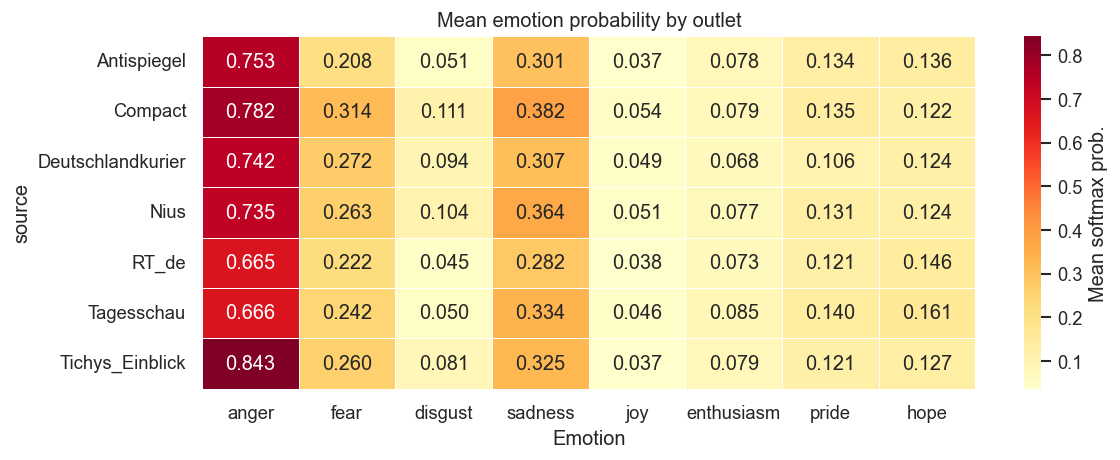

In [33]:
mean_by_outlet = df.groupby(OUTLET_COL, observed=True)[EMOTION_COLS].mean()
mean_by_outlet.columns = EMOTION_SHORT
mean_by_outlet = mean_by_outlet.sort_index()

plt.figure(figsize=(10, max(4, 0.35 * len(mean_by_outlet))))
sns.heatmap(
    mean_by_outlet,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Mean softmax prob."},
)
plt.title("Mean emotion probability by outlet")
plt.ylabel(OUTLET_COL)
plt.xlabel("Emotion")
plt.tight_layout()
plt.show()

In [34]:
# Calculate macro-mean (mean of outlet means) for anger and fear for all outlets except Tagesschau (alternative outlets), 
# and separately for Tagesschau

# Identify alternative outlets (all except Tagesschau)
alternative_outlets = mean_by_outlet.index[mean_by_outlet.index != "Tagesschau"]

# Calculate macro-mean for anger for alternative outlets
anger_macro_mean_alt = mean_by_outlet.loc[alternative_outlets, "anger"].mean()

# Calculate macro-mean for fear for alternative outlets
fear_macro_mean_alt = mean_by_outlet.loc[alternative_outlets, "fear"].mean()

# Get mean anger and fear for Tagesschau
anger_mean_tagesschau = mean_by_outlet.loc["Tagesschau", "anger"]
fear_mean_tagesschau = mean_by_outlet.loc["Tagesschau", "fear"]

print(f"Macro-mean anger (alternative outlets): {anger_macro_mean_alt:.4f}")
print(f"Tagesschau anger mean: {anger_mean_tagesschau:.4f}")
print(f"Macro-mean fear (alternative outlets): {fear_macro_mean_alt:.4f}")
print(f"Tagesschau fear mean: {fear_mean_tagesschau:.4f}")

Macro-mean anger (alternative outlets): 0.7535
Tagesschau anger mean: 0.6656
Macro-mean fear (alternative outlets): 0.2563
Tagesschau fear mean: 0.2424


Per-emotion macro-means  (alt media macro-mean vs Tagesschau)
             valence  alt_macro  tagesschau   delta
emotion                                            
anger       negative     0.7535      0.6656  0.0879
fear        negative     0.2563      0.2424  0.0139
disgust     negative     0.0811      0.0500  0.0311
sadness     negative     0.3268      0.3337 -0.0069
joy         positive     0.0443      0.0460 -0.0017
enthusiasm  positive     0.0757      0.0845 -0.0088
pride       positive     0.1246      0.1403 -0.0157
hope        positive     0.1298      0.1606 -0.0308

Aggregate valence (mean of macro-means within each valence group):
                   neg_avg  pos_avg  neg_minus_pos
group                                             
Alternative media   0.3544   0.0936         0.2608
Tagesschau          0.3229   0.1079         0.2151



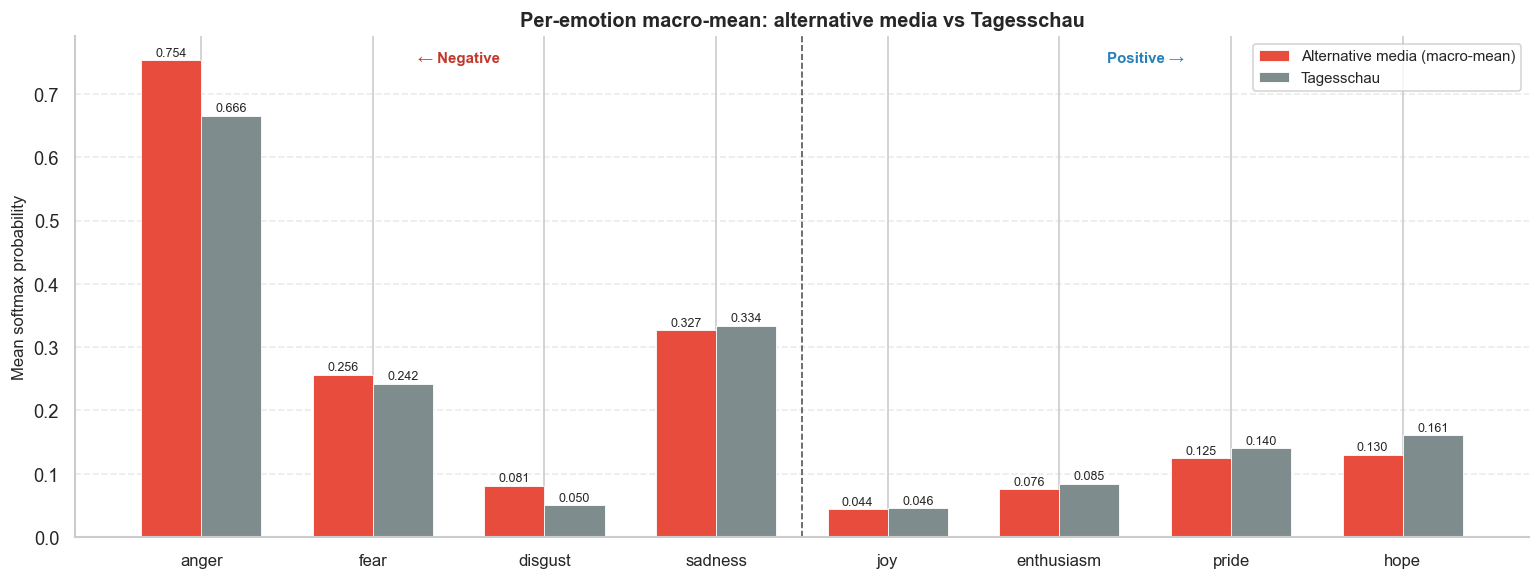

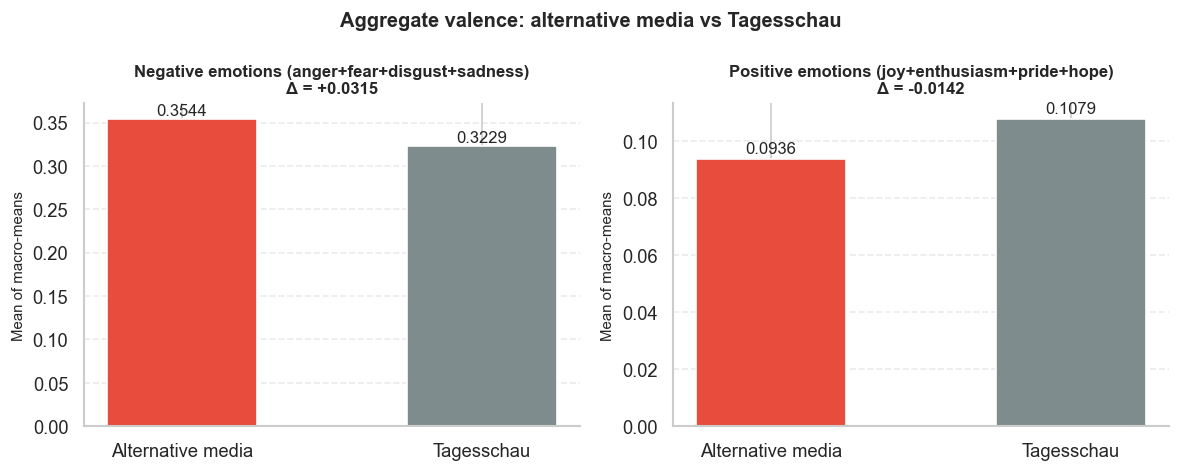

In [35]:
# ── Negative vs Positive emotions: macro-mean per outlet group vs Tagesschau ──
# Negative: anger, fear, disgust, sadness
# Positive: joy, enthusiasm, pride, hope
# Method: macro-mean = mean of per-outlet means (equal weight per outlet)

NEGATIVE = ["anger", "fear", "disgust", "sadness"]
POSITIVE = ["joy", "enthusiasm", "pride", "hope"]

# mean_by_outlet already has EMOTION_SHORT columns (no "emotion_" prefix)
alt_outlets = mean_by_outlet.index[mean_by_outlet.index != "Tagesschau"]
tg_row      = mean_by_outlet.loc[["Tagesschau"]]

alt_macro = mean_by_outlet.loc[alt_outlets].mean()   # macro-mean across alt outlets
tg_macro  = tg_row.iloc[0]                           # single outlet, so direct mean

# ── Per-emotion table ─────────────────────────────────────────────────────────
rows = []
for em in NEGATIVE + POSITIVE:
    rows.append({
        "emotion":    em,
        "valence":    "negative" if em in NEGATIVE else "positive",
        "alt_macro":  alt_macro[em],
        "tagesschau": tg_macro[em],
        "delta":      alt_macro[em] - tg_macro[em],
    })
tbl = pd.DataFrame(rows).set_index("emotion")
print("Per-emotion macro-means  (alt media macro-mean vs Tagesschau)")
print(tbl[["valence","alt_macro","tagesschau","delta"]].round(4).to_string())
print()

# ── Aggregate valence scores ──────────────────────────────────────────────────
agg = {
    "group":       ["Alternative media", "Tagesschau"],
    "neg_avg":     [alt_macro[NEGATIVE].mean(), tg_macro[NEGATIVE].mean()],
    "pos_avg":     [alt_macro[POSITIVE].mean(), tg_macro[POSITIVE].mean()],
}
agg_df = pd.DataFrame(agg).set_index("group")
agg_df["neg_minus_pos"] = agg_df["neg_avg"] - agg_df["pos_avg"]
print("Aggregate valence (mean of macro-means within each valence group):")
print(agg_df.round(4).to_string())
print()

# ── Chart 1: per-emotion grouped bars ────────────────────────────────────────
emotions_ordered = NEGATIVE + POSITIVE
x      = np.arange(len(emotions_ordered))
width  = 0.35
NEG_C  = "#c0392b"
POS_C  = "#2980b9"
ALT_C  = "#e74c3c"
TG_C   = "#7f8c8d"

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - width/2, [alt_macro[e] for e in emotions_ordered], width,
            label="Alternative media (macro-mean)", color=ALT_C, edgecolor="white", linewidth=0.5)
b2 = ax.bar(x + width/2, [tg_macro[e]  for e in emotions_ordered], width,
            label="Tagesschau", color=TG_C, edgecolor="white", linewidth=0.5)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7.5)

# Valence separator
ax.axvline(len(NEGATIVE) - 0.5, color="#555", linewidth=1.0, linestyle="--")
ax.text(len(NEGATIVE)/2 - 0.5,  ax.get_ylim()[1]*0.97, "← Negative",
        ha="center", va="top", fontsize=9, color=NEG_C, fontweight="bold")
ax.text(len(NEGATIVE) + len(POSITIVE)/2 - 0.5, ax.get_ylim()[1]*0.97, "Positive →",
        ha="center", va="top", fontsize=9, color=POS_C, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(emotions_ordered, fontsize=10)
ax.set_ylabel("Mean softmax probability", fontsize=10)
ax.set_title("Per-emotion macro-mean: alternative media vs Tagesschau", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# ── Chart 2: aggregate neg vs pos ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

for ax, (val_label, col, color) in zip(
    axes,
    [("Negative emotions (anger+fear+disgust+sadness)", "neg_avg", NEG_C),
     ("Positive emotions (joy+enthusiasm+pride+hope)",  "pos_avg", POS_C)]
):
    vals   = agg_df[col]
    colors = [ALT_C, TG_C]
    bars   = ax.bar(vals.index, vals.values, color=colors, edgecolor="white", width=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=10)
    delta = vals["Alternative media"] - vals["Tagesschau"]
    ax.set_title(f"{val_label}\nΔ = {delta:+.4f}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Mean of macro-means", fontsize=9)
    ax.spines[["top","right"]].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

fig.suptitle("Aggregate valence: alternative media vs Tagesschau", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
